importing libraries to perform the EDA (Exploratory Data Analysis)

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

data = pd.read_csv(r'C:\Users\Saumya\OneDrive\Pictures\Desktop\customer churn\raw\Customer Churn.csv')
data

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


Viewing the imported table

In [15]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

total charges data type converted to float which was previously string due to blanks.

In [17]:
data["TotalCharges"] = data["TotalCharges"].replace(" ", 0)
data["TotalCharges"] = data["TotalCharges"].astype("float")
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

check for nulls

In [19]:
data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [20]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


check for duplicated values on the unique id 

In [21]:
data["customerID"].duplicated().sum()

np.int64(0)

changes 0/1 to no/yes for easy understanding 

In [23]:
def change(num):
    if num == 1:
        return "YES"
    else:
        return "NO"
data["SeniorCitizen"] = data["SeniorCitizen"].apply(change)
data


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,NO,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,NO,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,NO,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,NO,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,NO,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,NO,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,NO,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,NO,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,YES,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


countplot for analysis of churn

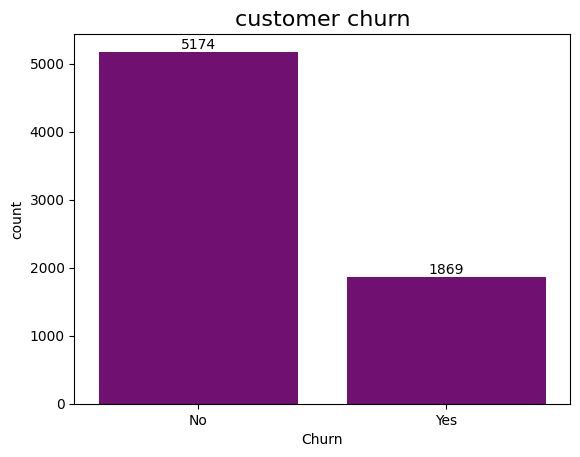

In [25]:
ax = sns.countplot(x = data["Churn"], color= "purple")
ax.bar_label(ax.containers[0])
plt.title("customer churn", fontsize= 16)
plt.show()

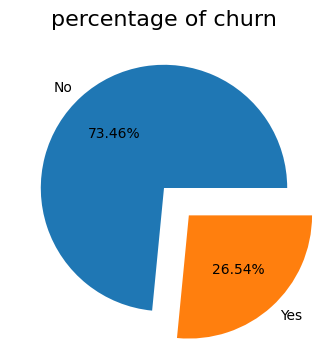

In [ ]:
GB = data.groupby("Churn").agg({'Churn':"count"})
GB
plt.figure(figsize=(4,4))
plt.pie(GB['Churn'], labels= GB.index,autopct="%1.2f%%", explode=(0,0.3))
plt.title("percentage of churn", fontsize= 16)
plt.show()


conclusion is that 26.54% of customers have churned out.

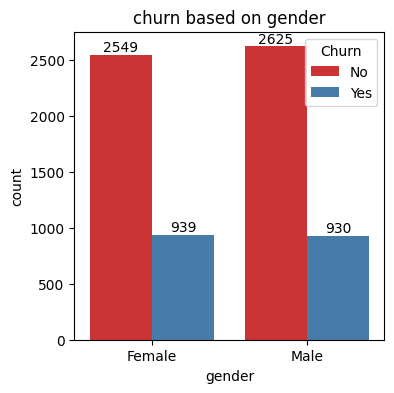

In [84]:
plt.figure(figsize=(4,4))
ab = sns.countplot(data= data, x="gender", hue= "Churn", palette='Set1')
ab.bar_label(ab.containers[0])
ab.bar_label(ab.containers[1])
plt.title("churn based on gender")
plt.show()

Churn is not much affected by Gender of customer.

[Text(0, 0, '2981'), Text(0, 0, '574')]

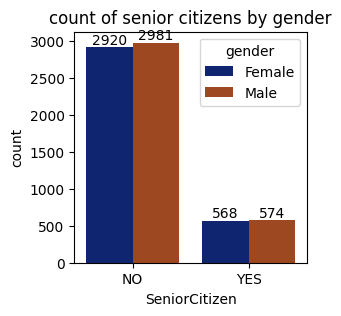

In [85]:
plt.figure(figsize=(3,3))
Citizens = sns.countplot(data=data, x="SeniorCitizen", palette='dark', hue="gender")
plt.title("count of senior citizens by gender")
Citizens.bar_label(Citizens.containers[0])
Citizens.bar_label(Citizens.containers[1])

There are fewer Senior Citizens as customers compared to youth.

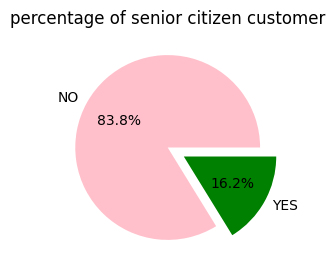

In [86]:
plt.figure(figsize=(3,3))
Group = data.groupby("SeniorCitizen").agg({'SeniorCitizen':"count"})
Group
plt.pie(Group["SeniorCitizen"],autopct="%1.1f%%", colors={"green","pink"}, explode=(0,0.2),labels=Group.index)
plt.title("percentage of senior citizen customer")
plt.show()

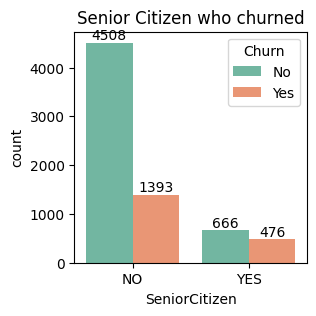

In [87]:
plt.figure(figsize=(3,3))
a= sns.countplot(data=data, x="SeniorCitizen",hue="Churn", palette="Set2")
a.bar_label(a.containers[0])
a.bar_label(a.containers[1])
plt.title("Senior Citizen who churned")
plt.show()


Youth churns more compared to Senior Citizens.

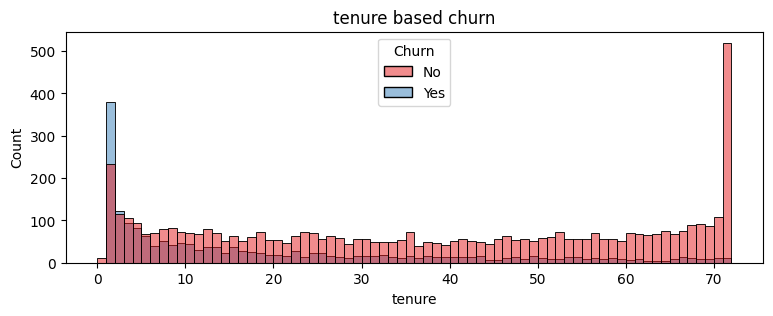

In [88]:
plt.figure(figsize=(9,3))
sns.histplot(data=data, x="tenure", hue="Churn", bins=72, palette="Set1")
plt.title("tenure based churn")
plt.show()

people who have used our services for a long time have stayed while the latest comers have churned.

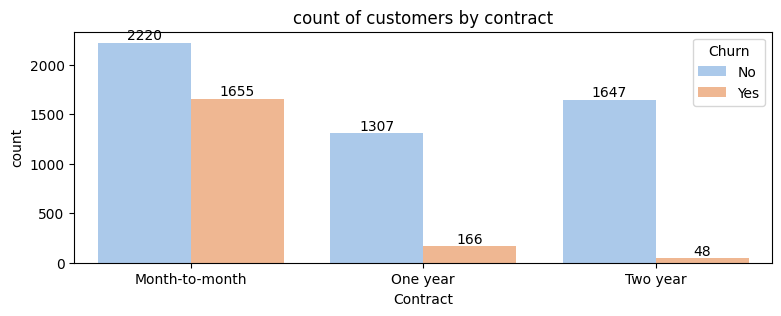

In [89]:
plt.figure(figsize=(9,3))
b= sns.countplot(data=data, x= "Contract", palette="pastel", hue="Churn")
b.bar_label(b.containers[0])
b.bar_label(b.containers[1])
plt.title("count of customers by contract")
plt.show()

people having month to month contract are likely to churn compared to customers with yearly or more contract.

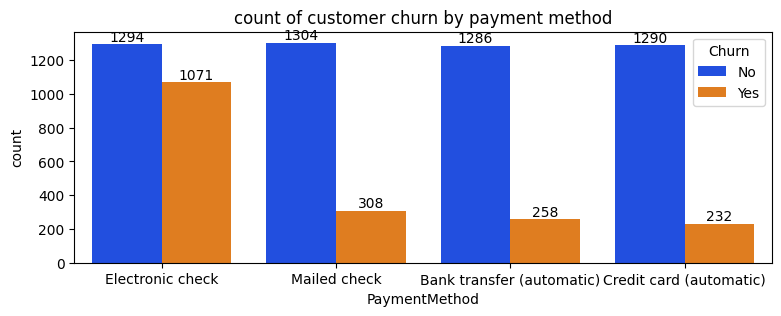

In [90]:
plt.figure(figsize=(9,3))
b= sns.countplot(data=data, x= "PaymentMethod", palette="bright", hue="Churn")
b.bar_label(b.containers[0])
b.bar_label(b.containers[1])
plt.title("count of customer churn by payment method")
plt.show()

churn is more in case of electronic churns.

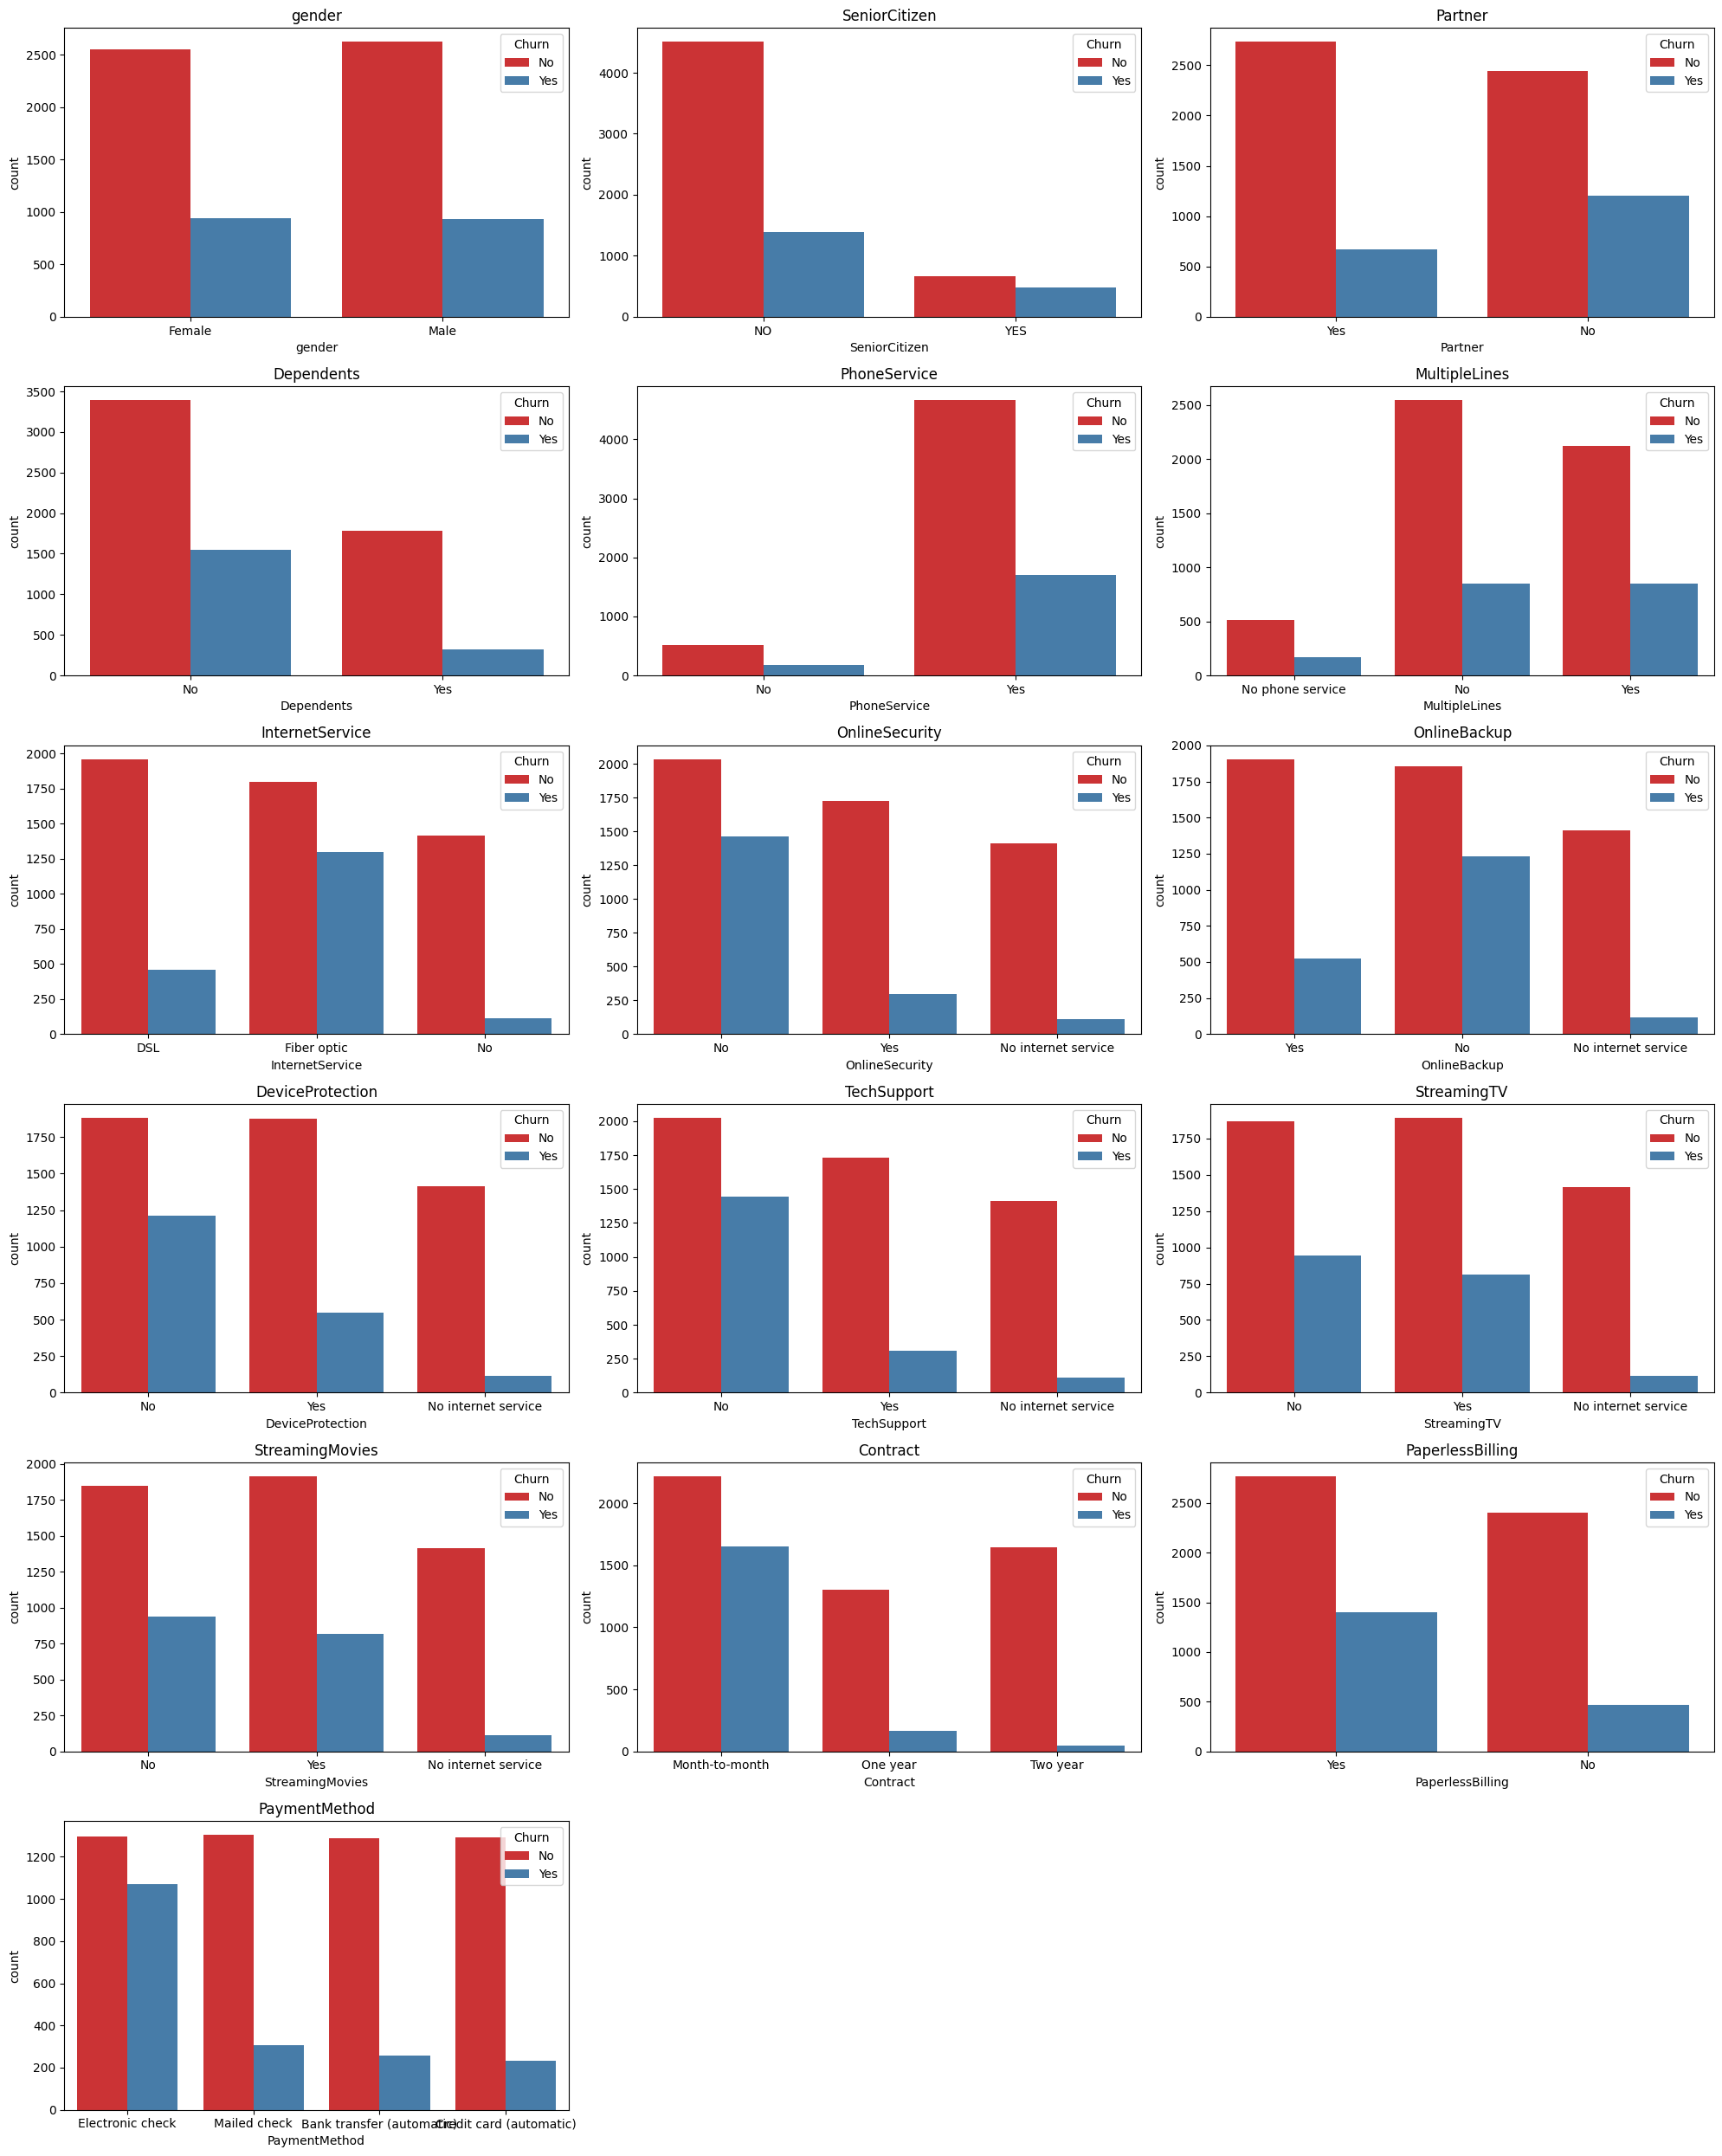

In [91]:
cols = ['gender','SeniorCitizen','Partner','Dependents','PhoneService',
        'MultipleLines','InternetService','OnlineSecurity','OnlineBackup',
        'DeviceProtection','TechSupport','StreamingTV','StreamingMovies',
        'Contract','PaperlessBilling','PaymentMethod']
plt.figure(figsize=(20,25))
for i, col in enumerate(cols):
    plt.subplot(6,3,i+1)
    sns.countplot(data=data, x=col, hue="Churn", palette="Set1")
    plt.title(col)
plt.tight_layout()
plt.show()

The subplots makes us understand about the factors which heavily contribute to churning of customers.